# 02 持仓变化/成交量周比率

本 Notebook 复现论文 Appendix B Figure 10：先计算每个交易日各到期合约的持仓变化绝对值相对成交量，再依次做日内跨合约平均、周内跨交易日平均和 12 周移动平均。

数据只从正式 silver 湖仓读取；本 Notebook 不写入 silver、gold 或其他数据文件。

## 在做什么

成交量记录一天发生了多少手交易，持仓量变化只记录收盘时仍留在市场中的净合约变化。把持仓变化与成交量放在一起，可以粗略区分“形成或解除隔夜持仓的交易”和“日内多次换手”。

## 经济意义

比率较低，通常意味着较多成交没有转化为收盘持仓净变化，可能对应更活跃的日内换手；比率较高，说明成交与持仓调整更同步。但同一天开仓与平仓可能相互抵消，所以它只能作为参与者交易期限的粗略代理，不能直接识别高频交易者。

## 论文口径

对第 $n$ 周最后一个交易日 $t_n$，论文定义：

$$R(t_n)=\frac{1}{N_n}\sum_{t_{n-1}<s\le t_n}\frac{1}{\#\mathcal{T}(s)}\sum_{T\in\mathcal{T}(s)}\frac{|oi(s,T)-oi(s-1,T)|}{v(s,T)}$$

$N_n$ 是该周交易日数，$\mathcal{T}(s)$ 是当天纳入计算的到期合约集合。粗线为完整 12 周均值：

$$\bar R(t_n)=\frac{1}{12}\sum_{k=1}^{12}R(t_{n-12+k})$$

默认样本为论文六品种与 2012-01-01 至 2021-12-31。

## 本指标的数据适用边界

论文分母要求当日成交量为正。进一步地，一手成交至多使持仓量改变一手，因此该统计量隐含 $|\Delta OI|/volume\le1$ 的交易记账边界。当前历史数据中少量临近到期或来源异常记录不满足这一边界；这些来源值仍保留在 silver，本 Notebook 只把它们标记为“不适用于该指标”、报告数量并排除，不做截尾、缩放或改写。

历史迁移行的 `open_interest_change` 全为空，所以严格从同一合约相邻记录的 `open_interest` 复算变化。读取时保留样本起点以前的数据，确保样本首日可以找到上一观测。

## 代码步骤

1. 定位项目根目录并导入权威日线 Schema。
2. 设置论文六品种、样本日期和 12 周窗口。
3. 读取目标品种截至样本末日的日线持仓、成交量和行情状态。
4. 逐合约复算相邻持仓变化，并报告指标不适用记录。
5. 计算日内跨合约平均、周内跨交易日平均和 12 周均线。
6. 绘制 Figure 10 风格六面板图并逐层人工复算。

## 第 1 步：环境、根目录和权威 Schema

In [1]:
from __future__ import annotations

import pathlib
import sys
from datetime import date

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.dataset as ds
from IPython.display import display

project_markers = [".git", ".env", "config/settings.py"]
current_path = pathlib.Path.cwd().resolve()  # 当前工作目录

for candidate_root in [current_path, *current_path.parents]:
    if all((candidate_root / marker).exists() for marker in project_markers):
        sys.path.insert(0, str(candidate_root))
        break
else:
    raise RuntimeError("未找到项目根目录")

PROJECT_ROOT = candidate_root

from config.data_contracts import FUTURES_DAILY_SCHEMA, arrow_to_pandas  # noqa: E402
from config.settings import settings  # noqa: E402

print(f"project_root: {PROJECT_ROOT}")
print(f"python: {sys.executable}")
print(f"schema_table: {FUTURES_DAILY_SCHEMA.metadata[b'table_name'].decode('utf-8')}")

project_root: E:\Latitude_Analytics_v2
python: E:\anaconda3\envs\latitude\python.exe
schema_table: fact_futures_daily


## 第 2 步：设置样本

将日期改为 `None` 可以扩展到湖仓边界。即使设置了样本起点，读取仍从品种最早历史开始，以便为样本首日取得同合约上一条持仓记录。

In [2]:
PAPER_START_DATE = date(2012, 1, 1)
PAPER_END_DATE = date(2021, 12, 31)
ANALYSIS_START_DATE: date | None = PAPER_START_DATE
ANALYSIS_END_DATE: date | None = PAPER_END_DATE
ROLLING_WEEKS = 12
RATIO_UPPER_BOUND_TOLERANCE = 1e-12

PRODUCTS = [
    {"exchange_code": "XSGE", "underlying_code": "RB", "label": "Steel Rebar"},
    {"exchange_code": "XSGE", "underlying_code": "CU", "label": "Copper"},
    {"exchange_code": "XSGE", "underlying_code": "NI", "label": "Nickel"},
    {"exchange_code": "XDCE", "underlying_code": "M", "label": "Soybean Meal"},
    {"exchange_code": "XDCE", "underlying_code": "L", "label": "Plastic"},
    {"exchange_code": "XDCE", "underlying_code": "C", "label": "Corn"},
]
PRODUCT_KEYS = [
    (product["exchange_code"], product["underlying_code"])
    for product in PRODUCTS
]
PRODUCT_LABEL_BY_KEY = {
    (product["exchange_code"], product["underlying_code"]): product["label"]
    for product in PRODUCTS
}

pd.DataFrame(PRODUCTS)

,exchange_code,underlying_code,label
0,XSGE,RB,Steel Rebar
1,XSGE,CU,Copper
2,XSGE,NI,Nickel
3,XDCE,M,Soybean Meal
4,XDCE,L,Plastic
5,XDCE,C,Corn


## 第 3 步：契约化读取持仓与成交量

从权威 Schema 取得表名、分区和字段类型。查询只筛选六个品种，并把样本末日下推到 Dataset；不下推样本起点是为了计算首日的上一持仓。

In [3]:
schema_metadata = {
    key.decode("utf-8"): value.decode("utf-8")
    for key, value in (FUTURES_DAILY_SCHEMA.metadata or {}).items()
}
table_name = schema_metadata["table_name"]
partition_columns = schema_metadata["partition_columns"].split(",")
daily_path = settings.futures_lake_root / "silver" / table_name
if not daily_path.exists():
    raise FileNotFoundError(f"日线事实表不存在：{daily_path}")

partitioning_schema = pa.schema(
    [
        pa.field(column_name, FUTURES_DAILY_SCHEMA.field(column_name).type)
        for column_name in partition_columns
    ]
)
daily_dataset = ds.dataset(
    daily_path,
    format="parquet",
    partitioning=ds.partitioning(partitioning_schema, flavor="hive"),
)

required_columns = [
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "volume",
    "open_interest",
    "has_market_data",
]
required_schema = pa.schema(
    [FUTURES_DAILY_SCHEMA.field(column_name) for column_name in required_columns]
)
for expected_field in required_schema:
    actual_field = daily_dataset.schema.field(expected_field.name)
    if actual_field.type != expected_field.type:
        raise TypeError(
            f"字段 {expected_field.name} 类型不匹配："
            f"期望 {expected_field.type}，实际 {actual_field.type}"
        )

product_filter = None
for exchange_code, underlying_code in PRODUCT_KEYS:
    current_product_filter = (
        (ds.field("exchange_code") == exchange_code)
        & (ds.field("underlying_code") == underlying_code)
    )
    product_filter = (
        current_product_filter
        if product_filter is None
        else product_filter | current_product_filter
    )

filter_expression = product_filter
if ANALYSIS_END_DATE is not None:
    filter_expression = filter_expression & (
        ds.field("trading_date") <= pa.scalar(ANALYSIS_END_DATE)
    )

selected_daily_table = daily_dataset.to_table(
    columns=required_columns,
    filter=filter_expression,
)
source_daily_df = arrow_to_pandas(selected_daily_table, required_schema)
source_daily_df["trading_date"] = pd.to_datetime(source_daily_df["trading_date"])
source_daily_df["volume"] = pd.to_numeric(
    source_daily_df["volume"], errors="coerce"
).astype(float)
source_daily_df["open_interest"] = pd.to_numeric(
    source_daily_df["open_interest"], errors="coerce"
).astype(float)
source_daily_df = source_daily_df.sort_values(
    ["exchange_code", "underlying_code", "contract_code", "trading_date"]
).reset_index(drop=True)

print(f"daily_path: {daily_path}")
print(f"source_rows_including_pre_sample_history: {len(source_daily_df):,}")

daily_path: E:\Latitude_Analytics_v2\03_Futures_Database\futures_lake\silver\fact_futures_daily
source_rows_including_pre_sample_history: 165,548


## 第 4 步：逐合约复算持仓变化并应用指标边界

先在完整读取历史中按合约排序并取上一条持仓，再筛选研究样本。状态表把缺少上一持仓、非正成交量和超过 100% 记账边界的记录分别列出。

In [4]:
source_daily_df["previous_open_interest"] = source_daily_df.groupby(
    ["exchange_code", "underlying_code", "contract_code"],
    observed=True,
)["open_interest"].shift(1)
source_daily_df["absolute_open_interest_change"] = (
    source_daily_df["open_interest"]
    - source_daily_df["previous_open_interest"]
).abs()

sample_mask = pd.Series(True, index=source_daily_df.index)
if ANALYSIS_START_DATE is not None:
    sample_mask &= source_daily_df["trading_date"] >= pd.Timestamp(ANALYSIS_START_DATE)
if ANALYSIS_END_DATE is not None:
    sample_mask &= source_daily_df["trading_date"] <= pd.Timestamp(ANALYSIS_END_DATE)

sample_market_df = source_daily_df.loc[
    sample_mask
    & source_daily_df["has_market_data"].fillna(False)
    & source_daily_df["open_interest"].notna()
].copy()
sample_market_df["metric_status"] = "valid"
sample_market_df.loc[
    sample_market_df["previous_open_interest"].isna(),
    "metric_status",
] = "missing_previous_open_interest"
sample_market_df.loc[
    (sample_market_df["metric_status"] == "valid")
    & (
        sample_market_df["volume"].isna()
        | (sample_market_df["volume"] <= 0)
    ),
    "metric_status",
] = "nonpositive_or_missing_volume"

positive_volume_mask = (
    (sample_market_df["metric_status"] == "valid")
    & (sample_market_df["volume"] > 0)
)
sample_market_df.loc[positive_volume_mask, "oi_change_to_volume"] = (
    sample_market_df.loc[positive_volume_mask, "absolute_open_interest_change"]
    / sample_market_df.loc[positive_volume_mask, "volume"]
)
sample_market_df.loc[
    positive_volume_mask
    & (
        sample_market_df["oi_change_to_volume"]
        > 1.0 + RATIO_UPPER_BOUND_TOLERANCE
    ),
    "metric_status",
] = "ratio_above_accounting_boundary"

contract_ratio_df = sample_market_df.loc[
    sample_market_df["metric_status"] == "valid",
    [
        "contract_code",
        "exchange_code",
        "underlying_code",
        "trading_date",
        "volume",
        "open_interest",
        "previous_open_interest",
        "absolute_open_interest_change",
        "oi_change_to_volume",
    ],
].copy()
if contract_ratio_df.empty:
    raise ValueError("没有满足指标边界的合约日记录")
if not np.isfinite(contract_ratio_df["oi_change_to_volume"].to_numpy(dtype=float)).all():
    raise ValueError("持仓变化/成交量包含非有限值")
if not contract_ratio_df["oi_change_to_volume"].between(0, 1).all():
    raise ValueError("有效持仓变化/成交量不在 [0, 1]")

status_counts_df = (
    sample_market_df.groupby(
        ["exchange_code", "underlying_code", "metric_status"],
        observed=True,
    )
    .size()
    .unstack("metric_status", fill_value=0)
    .reset_index()
)
for status_column in [
    "valid",
    "missing_previous_open_interest",
    "nonpositive_or_missing_volume",
    "ratio_above_accounting_boundary",
]:
    if status_column not in status_counts_df.columns:
        status_counts_df[status_column] = 0
status_counts_df["sample_market_rows"] = status_counts_df[
    [
        "valid",
        "missing_previous_open_interest",
        "nonpositive_or_missing_volume",
        "ratio_above_accounting_boundary",
    ]
].sum(axis=1)
status_counts_df["valid_share_pct"] = (
    status_counts_df["valid"] / status_counts_df["sample_market_rows"] * 100
)
status_counts_df["label"] = status_counts_df.apply(
    lambda row: PRODUCT_LABEL_BY_KEY[(row["exchange_code"], row["underlying_code"])],
    axis=1,
)
display(
    status_counts_df[
        [
            "exchange_code",
            "underlying_code",
            "label",
            "sample_market_rows",
            "valid",
            "missing_previous_open_interest",
            "nonpositive_or_missing_volume",
            "ratio_above_accounting_boundary",
            "valid_share_pct",
        ]
    ].sort_values(["exchange_code", "underlying_code"]).reset_index(drop=True)
)
print(f"valid_contract_day_rows: {len(contract_ratio_df):,}")

metric_status,exchange_code,underlying_code,label,sample_market_rows,valid,missing_previous_open_interest,nonpositive_or_missing_volume,ratio_above_accounting_boundary,valid_share_pct
0,XDCE,C,Corn,14586,13649,60,704,173,93.576032
1,XDCE,L,Plastic,29172,14590,120,14415,47,50.013712
2,XDCE,M,Soybean Meal,19448,18376,80,888,104,94.487865
3,XSGE,CU,Copper,29169,28976,120,61,12,99.338339
4,XSGE,NI,Nickel,19710,16923,90,2687,10,85.859970
5,XSGE,RB,Steel Rebar,29169,27877,120,1159,13,95.570640


valid_contract_day_rows: 120,391


## 第 5 步：日平均、周平均和 12 周均线

日度先对合约等权平均；周度再对该周实际存在的日度指标等权平均。周标签使用该周最后一个实际交易日，而不是固定写星期五。

In [5]:
daily_ratio_df = (
    contract_ratio_df.groupby(
        ["exchange_code", "underlying_code", "trading_date"],
        observed=True,
        as_index=False,
    )
    .agg(
        daily_ratio=("oi_change_to_volume", "mean"),
        valid_maturity_count=("contract_code", "size"),
    )
    .sort_values(["exchange_code", "underlying_code", "trading_date"])
    .reset_index(drop=True)
)
daily_ratio_df["week_period"] = daily_ratio_df["trading_date"].dt.to_period("W-FRI")

weekly_ratio_df = (
    daily_ratio_df.groupby(
        ["exchange_code", "underlying_code", "week_period"],
        observed=True,
        as_index=False,
    )
    .agg(
        week_last_trading_date=("trading_date", "max"),
        trading_days=("trading_date", "nunique"),
        weekly_ratio=("daily_ratio", "mean"),
        mean_valid_maturity_count=("valid_maturity_count", "mean"),
    )
    .sort_values(["exchange_code", "underlying_code", "week_last_trading_date"])
    .reset_index(drop=True)
)
weekly_ratio_df["ratio_12w_mean"] = (
    weekly_ratio_df.groupby(
        ["exchange_code", "underlying_code"],
        observed=True,
    )["weekly_ratio"]
    .transform(
        lambda ratio_series: ratio_series.rolling(
            window=ROLLING_WEEKS,
            min_periods=ROLLING_WEEKS,
        ).mean()
    )
)

weekly_summary_df = (
    weekly_ratio_df.groupby(
        ["exchange_code", "underlying_code"],
        observed=True,
        as_index=False,
    )
    .agg(
        first_week=("week_last_trading_date", "min"),
        last_week=("week_last_trading_date", "max"),
        weeks=("week_last_trading_date", "size"),
        mean_weekly_ratio=("weekly_ratio", "mean"),
        median_weekly_ratio=("weekly_ratio", "median"),
        max_weekly_ratio=("weekly_ratio", "max"),
    )
)
weekly_summary_df["label"] = weekly_summary_df.apply(
    lambda row: PRODUCT_LABEL_BY_KEY[(row["exchange_code"], row["underlying_code"])],
    axis=1,
)
for ratio_column in ["mean_weekly_ratio", "median_weekly_ratio", "max_weekly_ratio"]:
    weekly_summary_df[f"{ratio_column}_pct"] = weekly_summary_df[ratio_column] * 100
display(
    weekly_summary_df[
        [
            "exchange_code",
            "underlying_code",
            "label",
            "first_week",
            "last_week",
            "weeks",
            "mean_weekly_ratio_pct",
            "median_weekly_ratio_pct",
            "max_weekly_ratio_pct",
        ]
    ].sort_values(["exchange_code", "underlying_code"]).reset_index(drop=True)
)
print(f"daily_ratio_rows: {len(daily_ratio_df):,}")
print(f"weekly_ratio_rows: {len(weekly_ratio_df):,}")

,exchange_code,underlying_code,label,first_week,last_week,weeks,mean_weekly_ratio_pct,median_weekly_ratio_pct,max_weekly_ratio_pct
0,XDCE,C,Corn,2012-01-06,2021-12-31,513,19.540165,19.229046,45.525442
1,XDCE,L,Plastic,2012-01-06,2021-12-31,513,23.434195,22.952416,50.781986
2,XDCE,M,Soybean Meal,2012-01-06,2021-12-31,513,18.665648,18.360068,40.475747
3,XSGE,CU,Copper,2012-01-06,2021-12-31,513,19.161490,18.936829,36.210808
4,XSGE,NI,Nickel,2015-04-03,2021-12-31,347,22.534888,21.967402,42.005143
5,XSGE,RB,Steel Rebar,2012-01-06,2021-12-31,513,21.923244,21.525191,42.586049


daily_ratio_rows: 13,801
weekly_ratio_rows: 2,912


## 第 6 步：绘制 Figure 10 风格图

浅色线为周度原始比率，粗线为完整 12 周移动平均。纵轴按百分比显示，各面板保留自身尺度。

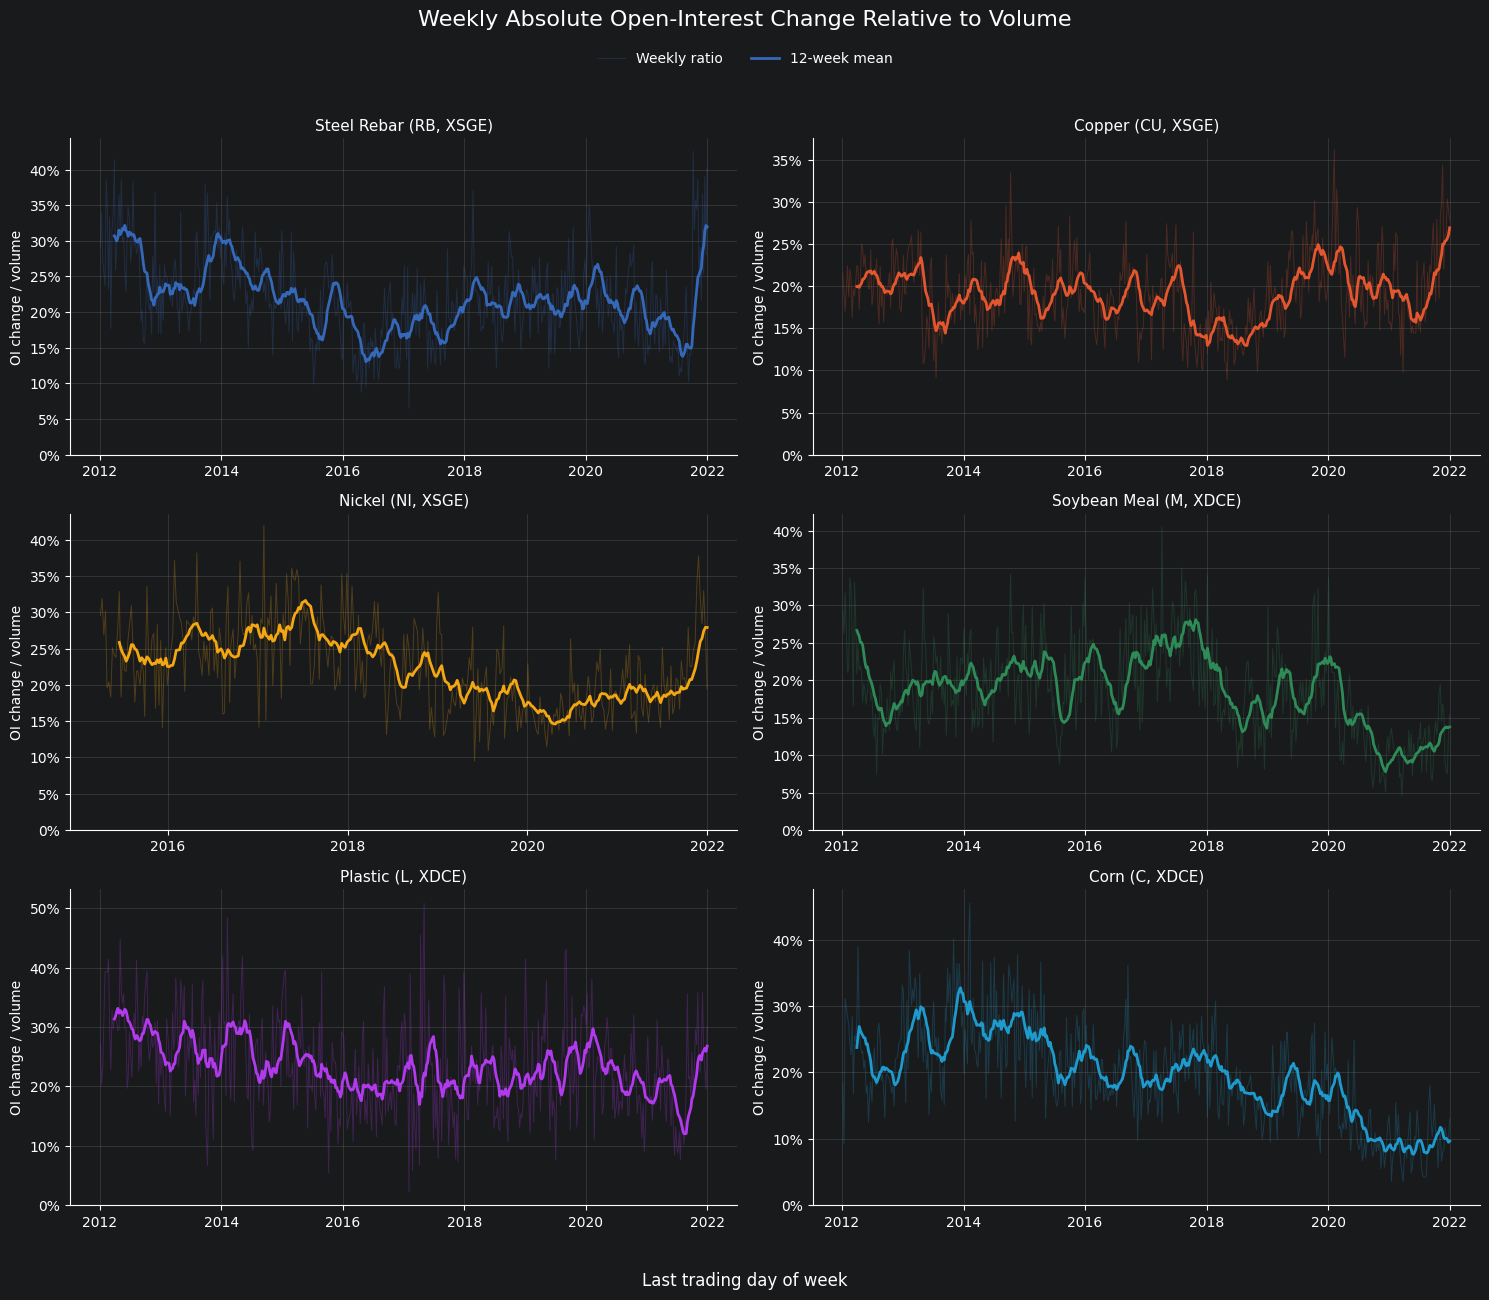

In [6]:
colors = {
    ("XSGE", "RB"): "#3568B8",
    ("XSGE", "CU"): "#E4572E",
    ("XSGE", "NI"): "#F3A712",
    ("XDCE", "M"): "#2E8B57",
    ("XDCE", "L"): "#B23AEE",
    ("XDCE", "C"): "#1E9ACD",
}

figure, axes = plt.subplots(3, 2, figsize=(15, 13), sharex=False)
legend_handles = None
for axis, product in zip(axes.flat, PRODUCTS):
    product_key = (product["exchange_code"], product["underlying_code"])
    product_weekly_df = weekly_ratio_df.loc[
        (weekly_ratio_df["exchange_code"] == product_key[0])
        & (weekly_ratio_df["underlying_code"] == product_key[1])
    ].sort_values("week_last_trading_date")
    if product_weekly_df.empty:
        raise AssertionError(f"绘图品种没有数据：{product_key}")

    weekly_line = axis.plot(
        product_weekly_df["week_last_trading_date"],
        product_weekly_df["weekly_ratio"] * 100,
        color=colors[product_key],
        linewidth=0.7,
        alpha=0.25,
        label="Weekly ratio",
    )[0]
    moving_average_line = axis.plot(
        product_weekly_df["week_last_trading_date"],
        product_weekly_df["ratio_12w_mean"] * 100,
        color=colors[product_key],
        linewidth=2.0,
        label="12-week mean",
    )[0]
    if legend_handles is None:
        legend_handles = [weekly_line, moving_average_line]

    axis.set_title(
        f"{product['label']} ({product['underlying_code']}, {product['exchange_code']})",
        fontsize=11,
    )
    axis.set_ylabel("OI change / volume")
    axis.yaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))
    axis.set_ylim(bottom=0)
    axis.xaxis.set_major_locator(mdates.YearLocator(2))
    axis.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    axis.grid(alpha=0.2, linewidth=0.6)
    axis.spines[["top", "right"]].set_visible(False)

figure.suptitle(
    "Weekly Absolute Open-Interest Change Relative to Volume",
    fontsize=16,
    y=0.995,
)
figure.supxlabel("Last trading day of week")
figure.legend(
    legend_handles,
    ["Weekly ratio", "12-week mean"],
    loc="upper center",
    bbox_to_anchor=(0.5, 0.972),
    ncol=2,
    frameon=False,
)
figure.tight_layout(rect=(0, 0.02, 1, 0.95))
plt.show()

## 验证

下面分别人工复算每个品种的第一个日平均、第一周平均和第一个完整 12 周平均，并确认六个图表面板全部存在。

In [7]:
validated_product_count = 0
for product_key in PRODUCT_KEYS:
    product_contract_df = contract_ratio_df.loc[
        (contract_ratio_df["exchange_code"] == product_key[0])
        & (contract_ratio_df["underlying_code"] == product_key[1])
    ].sort_values(["trading_date", "contract_code"])
    product_daily_df = daily_ratio_df.loc[
        (daily_ratio_df["exchange_code"] == product_key[0])
        & (daily_ratio_df["underlying_code"] == product_key[1])
    ].sort_values("trading_date").reset_index(drop=True)
    product_weekly_df = weekly_ratio_df.loc[
        (weekly_ratio_df["exchange_code"] == product_key[0])
        & (weekly_ratio_df["underlying_code"] == product_key[1])
    ].sort_values("week_last_trading_date").reset_index(drop=True)
    if product_contract_df.empty or product_daily_df.empty or len(product_weekly_df) < ROLLING_WEEKS:
        raise AssertionError(f"验证数据不足：{product_key}")

    first_trading_date = product_daily_df.loc[0, "trading_date"]
    expected_first_daily_ratio = product_contract_df.loc[
        product_contract_df["trading_date"] == first_trading_date,
        "oi_change_to_volume",
    ].mean()
    actual_first_daily_ratio = product_daily_df.loc[0, "daily_ratio"]
    if not np.isclose(actual_first_daily_ratio, expected_first_daily_ratio, rtol=1e-12, atol=1e-12):
        raise AssertionError(f"日度跨合约平均复算不一致：{product_key}")

    first_week_period = product_weekly_df.loc[0, "week_period"]
    expected_first_weekly_ratio = product_daily_df.loc[
        product_daily_df["week_period"] == first_week_period,
        "daily_ratio",
    ].mean()
    actual_first_weekly_ratio = product_weekly_df.loc[0, "weekly_ratio"]
    if not np.isclose(actual_first_weekly_ratio, expected_first_weekly_ratio, rtol=1e-12, atol=1e-12):
        raise AssertionError(f"周度跨交易日平均复算不一致：{product_key}")

    expected_first_complete_12w_mean = product_weekly_df.loc[
        : ROLLING_WEEKS - 1, "weekly_ratio"
    ].mean()
    actual_first_complete_12w_mean = product_weekly_df.loc[
        ROLLING_WEEKS - 1, "ratio_12w_mean"
    ]
    if not np.isclose(
        actual_first_complete_12w_mean,
        expected_first_complete_12w_mean,
        rtol=1e-12,
        atol=1e-12,
    ):
        raise AssertionError(f"12 周均线复算不一致：{product_key}")
    if product_weekly_df.loc[: ROLLING_WEEKS - 2, "ratio_12w_mean"].notna().any():
        raise AssertionError(f"完整 12 周前不应产生均线：{product_key}")
    validated_product_count += 1

if validated_product_count != len(PRODUCTS):
    raise AssertionError(
        f"验证品种数不一致：期望 {len(PRODUCTS)}，实际 {validated_product_count}"
    )
if len(axes.flat) != len(PRODUCTS):
    raise AssertionError("图表面板数不是 6")

print(
    f"validation_ok: {validated_product_count} products, "
    f"{len(contract_ratio_df):,} valid contract-day ratios, "
    f"{len(daily_ratio_df):,} daily ratios, "
    f"{len(weekly_ratio_df):,} weekly ratios, "
    f"{len(axes.flat)} plot panels"
)

validation_ok: 6 products, 120,391 valid contract-day ratios, 13,801 daily ratios, 2,912 weekly ratios, 6 plot panels


## 如何解释结果

- 周度浅色线保留短期交易结构变化，12 周粗线更适合观察持续趋势。
- 比率下降表示单位成交量对应的收盘持仓调整变少，和日内换手增加相容，但不是对日内交易者数量的直接估计。
- 跨品种比较前要注意合约月份结构、交割制度和产业参与者不同。
- 指标不适用记录已经单独计数；它们没有被修改，也没有通过缩尾或上限截断混入统计。
- 图形是描述性结果，不能单独把趋势归因于监管或算法交易发展。